⚠️ [TIME: 22s] SUDDEN RAIN!
🏁 Race Finished!


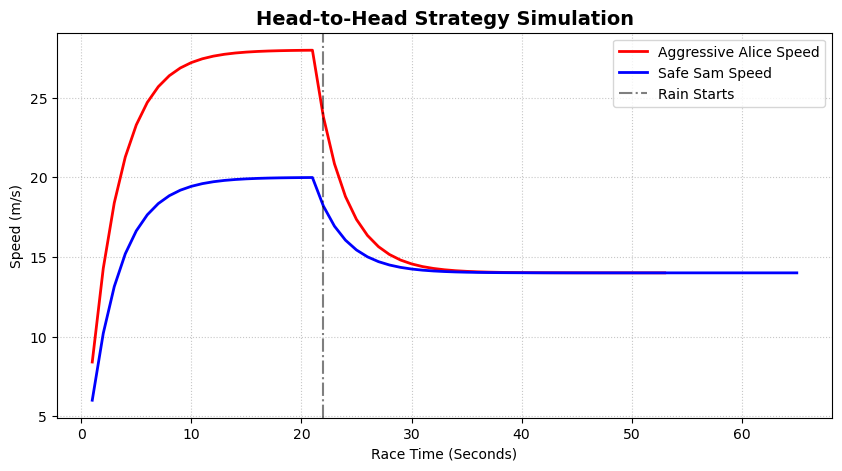

In [7]:
import matplotlib.pyplot as plt

# --- 🏗️ THE BLUEPRINT (CLASS) ---
class RaceCar:
    # 1. The Initialization (Setup)
    def __init__(self, name, strategy):
        self.name = name
        self.strategy = strategy
        self.distance = 0
        self.speed = 0
        self.fuel = 100.0
        
        # Each car carries its own telemetry logs
        self.history = {'time': [], 'speed': [], 'fuel': []}

    # 2. The Engine & Brain (Method)
    def drive(self, current_time, is_raining):
        # If the car is finished or out of gas, stop driving
        if self.distance >= 1000 or self.fuel <= 0:
            return 
            
        # --- 🧠 UNIQUE STRATEGIES ---
        if self.strategy == 'aggressive':
            # Fast target, but risky on fuel
            target_speed = 28 if self.fuel > 15 else 12
        else: # 'safe' strategy
            # Slower, but highly fuel efficient
            target_speed = 20 if self.fuel > 10 else 12

        # Chaos Adaptation
        if is_raining:
            target_speed = min(target_speed, 14) # Both cars must slow down in rain

        # --- 🏎️ P-CONTROLLER PHYSICS ---
        error = target_speed - self.speed
        Kp = 0.3
        speed_change = Kp * error
        self.speed += speed_change

        if speed_change > 0:
            self.fuel -= (0.4 * speed_change)
        else:
            self.fuel -= 0.05
            
        self.distance += self.speed
        
        # Log telemetry for this specific car
        self.history['time'].append(current_time)
        self.history['speed'].append(self.speed)
        self.history['fuel'].append(self.fuel)

# --- 🏁 THE RACE TRACK (MAIN LOOP) ---

# Spawn two cars from our blueprint
car1 = RaceCar("Aggressive Alice", "aggressive")
car2 = RaceCar("Safe Sam", "safe")

seconds = 0
rain_triggered = False
rain_time = 0

# Race continues until BOTH cars are finished or empty
while (car1.distance < 1000 and car1.fuel > 0) or (car2.distance < 1000 and car2.fuel > 0):
    seconds += 1
    
    # Trigger rain if ANY car hits 500m
    if not rain_triggered and (car1.distance >= 500 or car2.distance >= 500):
        rain_triggered = True
        rain_time = seconds
        print(f"⚠️ [TIME: {seconds}s] SUDDEN RAIN!")

    # Tell both cars to calculate their physics for this second
    car1.drive(seconds, rain_triggered)
    car2.drive(seconds, rain_triggered)

print("🏁 Race Finished!")

# --- 📈 THE VISUALIZATION ---
plt.figure(figsize=(10, 5))

# Plot Car 1 (Alice)
plt.plot(car1.history['time'], car1.history['speed'], label=f'{car1.name} Speed', color='red', linewidth=2)
# Plot Car 2 (Sam)
plt.plot(car2.history['time'], car2.history['speed'], label=f'{car2.name} Speed', color='blue', linewidth=2)

plt.axvline(x=rain_time, color='black', linestyle='-.', alpha=0.5, label='Rain Starts')

plt.title("Head-to-Head Strategy Simulation", fontsize=14, fontweight='bold')
plt.xlabel("Race Time (Seconds)")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [8]:
# --- 📊 AUTOMATED POST-RACE ANALYSIS ---
def analyze_race(car1, car2):
    print("\n" + "="*45)
    print("🏆 OFFICIAL POST-RACE TELEMETRY REPORT 🏆")
    print("="*45)
    
    # Put our cars in a list so we can loop through them easily
    cars = [car1, car2]
    stats = []
    
    for car in cars:
        # KPI 1: Did they actually cross the finish line?
        finished = car.distance >= 1000
        
        # KPI 2: What was their final time? (The last timestamp in their log)
        final_time = car.history['time'][-1]
        
        # KPI 3: What was their highest speed?
        max_speed = max(car.history['speed'])
        
        # Save these stats into a dictionary
        stats.append({
            'name': car.name,
            'finished': finished,
            'distance': car.distance,
            'time': final_time,
            'fuel': max(0, car.fuel), # max(0) prevents showing negative fuel
            'max_speed': max_speed
        })
        
    # --- 🥇 ALGORITHMIC RANKING (FIND THE WINNER) ---
    # Sorting logic: We want True (finished) to beat False. 
    # If both finished, we want the lowest time. 
    # If neither finished, we want the highest distance.
    stats.sort(key=lambda x: (x['finished'], -x['time'] if x['finished'] else x['distance']), reverse=True)
    
    winner = stats[0]
    print(f"🥇 WINNER: {winner['name'].upper()}!\n")
    
    # --- 📝 PRINT THE LEADERBOARD TABLE ---
    print(f"{'Driver':<18} | {'Status':<10} | {'Time':<8} | {'Max Spd':<8} | {'Fuel Left'}")
    print("-" * 65)
    
    for r in stats:
        status = "FINISHED" if r['finished'] else "DNF"
        time_str = f"{r['time']}s" if r['finished'] else "N/A"
        print(f"{r['name']:<18} | {status:<10} | {time_str:<8} | {r['max_speed']:<8.1f} | {r['fuel']:.1f}%")

# Execute the analysis
analyze_race(car1, car2)


🏆 OFFICIAL POST-RACE TELEMETRY REPORT 🏆
🥇 WINNER: AGGRESSIVE ALICE!

Driver             | Status     | Time     | Max Spd  | Fuel Left
-----------------------------------------------------------------
Aggressive Alice   | FINISHED   | 53s      | 28.0     | 87.2%
Safe Sam           | FINISHED   | 65s      | 20.0     | 89.8%
